In [6]:
import numpy as np
import pandas as pd
import timeit
from skbio.stats.composition._ancombc import ancombc

In [7]:
import string

In [8]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

In [22]:
from matplotlib import ticker

### Benchmark results on simulated dataset

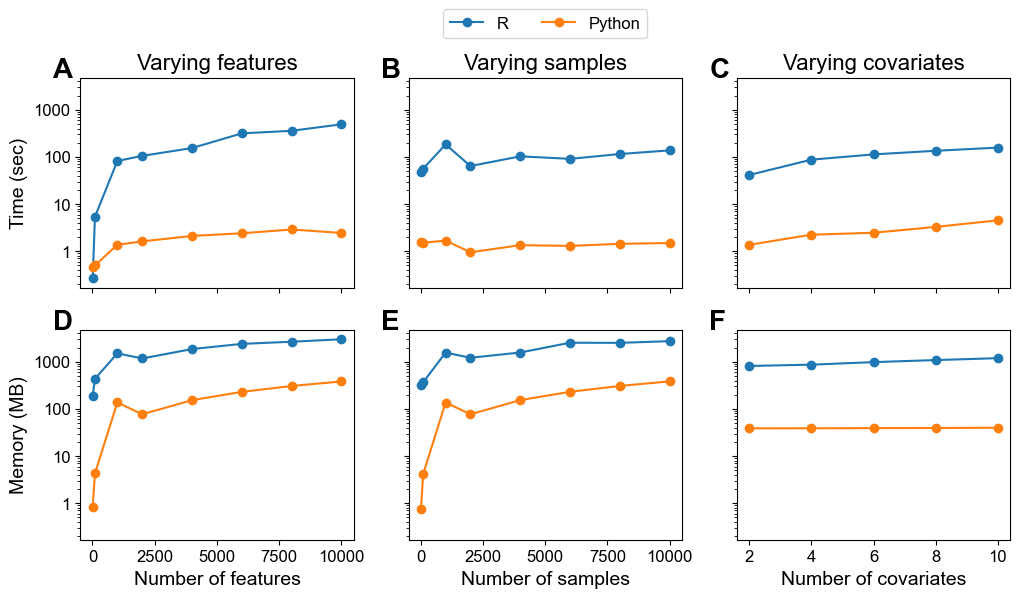

In [260]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6), sharey=True, sharex='col')

res = pd.read_csv('./benchmark_metrics_r.csv', index_col=0)
res_py = pd.read_csv('benchmark_metrics_python.csv', index_col=0)
res_py = res_py[res_py.index != 'Full_matrix']
x = np.array([10, 100, 1000, 2000, 4000, 6000, 8000, 10000])

y = []
y_py = []
y_mem = []
y_mem_py = []
for i in x:
    y.append(res[res['Features'] == i]['Time_Sec'].mean())
    y_mem.append(res[res['Features'] == i]['Memory_Used_MB'].mean())
    y_py.append(res_py[res_py['Features'] == i]['Time_Sec'].mean())
    y_mem_py.append(res_py[res_py['Features'] == i]['Memory_Peak_MB'].mean())
y = np.array(y)
y_py = np.array(y_py)
y_mem = np.array(y_mem)
y_mem_py = np.array(y_mem_py)

axes[0, 0].plot(x, y, marker='o', label='R')
axes[0, 0].plot(x, y_py, marker='o', label='Python')
axes[0, 0].set_title("Varying features")
axes[0, 0].set_yscale('log')
axes[0, 0].yaxis.set_major_formatter(ticker.ScalarFormatter())
axes[0, 0].ticklabel_format(style='plain', axis='y')
axes[0, 0].set_ylabel("Time (sec)")


axes[1, 0].plot(x, y_mem, marker='o', label='R')
axes[1, 0].plot(x, y_mem_py, marker='o', label='Python')
axes[1, 0].set_xlabel("Number of features")

axes[1, 0].set_ylabel("Memory (MB)")


y = []
y_py = []
y_mem = []
y_mem_py = []
for i in x:
    y.append(res[res['Samples'] == i]['Time_Sec'].mean())
    y_mem.append(res[res['Samples'] == i]['Memory_Used_MB'].mean())
    y_py.append(res_py[res_py['Samples'] == i]['Time_Sec'].mean())
    y_mem_py.append(res_py[res_py['Samples'] == i]['Memory_Peak_MB'].mean())
y = np.array(y)
y_py = np.array(y_py)
y_mem = np.array(y_mem)
y_mem_py = np.array(y_mem_py)

axes[0, 1].plot(x, y, marker='o', label='R')
axes[0, 1].plot(x, y_py, marker='o', label='Python')
axes[0, 1].set_title("Varying samples")

axes[1, 1].plot(x, y_mem, marker='o', label='R')
axes[1, 1].plot(x, y_mem_py, marker='o', label='Python')
axes[1, 1].set_xlabel("Number of samples")


x = np.array([2, 4, 6, 8, 10])
res_py = pd.read_csv('./benchmark_cov_py.csv')
res_r = pd.read_csv('./benchmark_cov_r.csv')
x = np.array([2,4,6,8,10])
y = []
y_py = []
y_mem = []
y_mem_py = []
for i in x:
    y.append(res_r[res_r['N_Cov'] == i]['Time_Sec'].mean())
    y_mem.append(res_r[res_r['N_Cov'] == i]['Memory_Used_MB'].mean())
    y_py.append(res_py[res_py['N_cov'] == i]['Time_Sec'].mean())
    y_mem_py.append(res_py[res_py['N_cov'] == i]['Memory_Peak_MB'].mean())
y = np.array(y)
y_py = np.array(y_py)
y_mem = np.array(y_mem)
y_mem_py = np.array(y_mem_py)

axes[0, 2].set_title("Varying covariates")
axes[0, 2].plot(x, y, marker='o', label='R')
axes[0, 2].plot(x, y_py, marker='o', label='Python')

axes[1, 2].plot(x, y_mem, marker='o', label='R')
axes[1, 2].plot(x, y_mem_py, marker='o', label='Python')
axes[1, 2].set_xlabel("Number of covariates")

axes[0, 1].legend(loc='lower center', bbox_to_anchor=(0.5, 1.15), ncol=2)
# ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.15),
#           ncol=2, fancybox=True, shadow=True)
for n, ax in enumerate(axes.flatten() ):
    ax.text(-0.1, 1.0, string.ascii_uppercase[n], transform=ax.transAxes, 
            size=20, weight='bold')

#plt.tight_layout()
plt.show()

### analysis on real datasets

In [54]:
from skbio.stats.composition._ancombc import ancombc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [55]:
def plot_cm(exp, obs, title):
    np.set_printoptions(precision=2)
    cm = confusion_matrix(exp.sort_index(axis=1).to_numpy().flatten(), obs.sort_index(axis=1).to_numpy().flatten().astype(bool))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['True', 'False'])
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.xlabel('R')
    plt.ylabel('Python')
    plt.show()

In [ ]:
def format_res(df): # df is the output matrix from python implementation
    obs = df["Signif"].unstack()
    obs.columns.name = None
    obs.index.name = "taxon"
    obs = obs.rename(columns={"Intercept": "(Intercept)"})
    for c in obs.columns:
        obs = obs.rename(columns={c: c.replace("[T.", "").replace("]", "")})
    obs = obs.sort_index(axis=1)
    obs = obs.sort_index
    return obs

#### HITChip dataset

In [94]:
pseq = pd.read_csv('./dataset/pseq_feature_table_subset.csv', index_col=0)
meta_data = pd.read_csv('./dataset/pseq_meta_data_subset.csv', index_col=0)

In [95]:
table = pseq.to_numpy().T
meta_data = meta_data.dropna(axis=1, how='any')
meta_data['bmi'] = pd.Categorical(meta_data['bmi'], categories=['obese', 'overweight', 'lean'])

In [96]:
res_py = ancombc(table+1, meta_data, "age + region + bmi", max_iter=100)

In [97]:
obs_pseq = res_py["Signif"].unstack()
obs_pseq.columns.name = None
obs_pseq.index.name = "taxon"
obs_pseq = obs_pseq.rename(columns={"Intercept": "(Intercept)"})
for c in obs_pseq.columns:
    obs_pseq = obs_pseq.rename(columns={c: c.replace("[T.", "").replace("]", "")})

In [98]:
exp_pseq = pd.read_csv('./dataset/pseq_subset_out_res_diff_abn.csv', index_col='taxon').drop("Unnamed: 0", axis=1)

In [99]:
obs_pseq.index = exp_pseq.index

In [21]:
similarity = exp.eq(obs).sum().sum() / exp.size

In [22]:
similarity

np.float64(1.0)

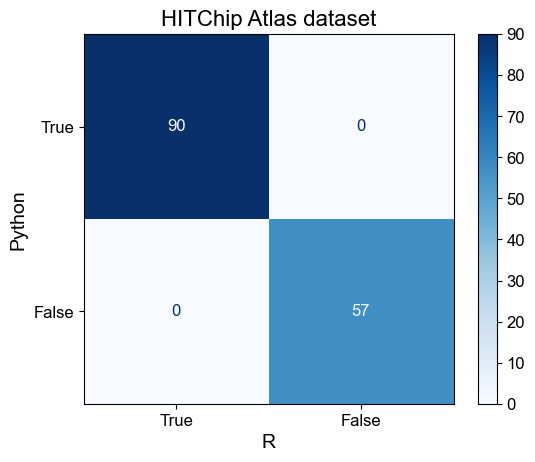

In [350]:
np.set_printoptions(precision=2)
cm = confusion_matrix(exp.sort_index(axis=1).to_numpy().flatten(), obs.sort_index(axis=1).to_numpy().flatten().astype(bool))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['True', 'False'])
disp.plot(cmap='Blues')
plt.title("HITChip Atlas dataset")
plt.xlabel('R')
plt.ylabel('Python')
plt.show()

#### EMP500 dataset

the subset of EMP500 contains 753 samples × 8351 features

In [87]:
table = pd.read_csv('./dataset/feature_emp500_subset.csv', index_col=0)
meta_data = pd.read_csv('./dataset/metadata_emp500_subset.csv', index_col=0)
res_py = ancombc(table+1, meta_data, "empo_1")

In [88]:
obs_emp = res_py["Signif"].unstack()
obs_emp .columns.name = None
obs_emp .index.name = "taxon"
obs_emp  = obs_emp .rename(columns={"Intercept": "(Intercept)"})
for c in obs_emp .columns:
    obs_emp  = obs_emp .rename(columns={c: c.replace("[T.", "").replace("]", "")})
obs_emp  = obs_emp .sort_index()

In [89]:
exp_emp = pd.read_csv('./res/emp500_subset_diff_abn_r.csv', index_col='taxon').drop("Unnamed: 0", axis=1)

In [90]:
exp_emp.index = exp_emp.index.str[1:]
exp_emp = exp_emp.sort_index()

In [91]:
similarity = exp.eq(obs).sum().sum() / exp.size
print(similarity)

1.0


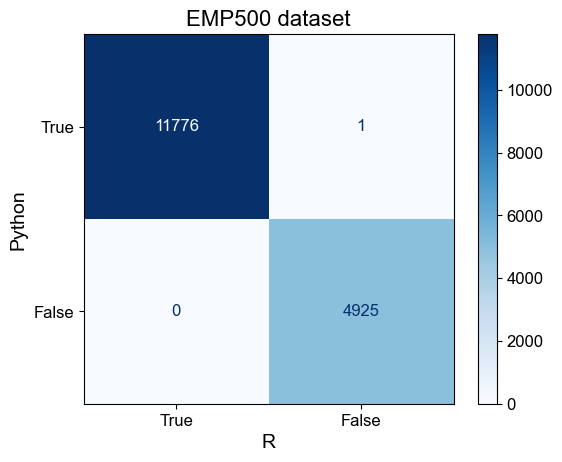

In [271]:
plot_cm(exp, obs, "EMP500 dataset")

#### single cell dataset

In [74]:
table = pd.read_pickle('~/git/ath/dataset/v7_features_downsample_add_ct_train.pkl')

In [75]:
#table.index = sample_id
table = table.iloc[:, :-9]

In [76]:
normalized_matrix = table.to_numpy()
raw_counts = np.expm1(normalized_matrix)
raw_counts = (2 ** normalized_matrix) - 1
raw_counts[raw_counts < 0] = 0
count_table = np.rint(raw_counts).astype(int)

In [77]:
cond = table.index.str.rsplit('_', n=1).str[0]

In [78]:
sample_id = table.index.str.split('_').str[-1]

In [79]:
ct = table.iloc[:, -9:]

In [80]:
ct = ct.idxmax(axis=1).to_numpy()

In [81]:
meta_data = pd.DataFrame({'cond': cond.to_numpy(), 'cell_tpye':ct}, index=sample_id)

In [82]:
res_py = ancombc(count_table+1, meta_data, "cond") # input is sample by feature

In [83]:
obs = res_py["Signif"].unstack()
obs.columns.name = None
obs.index.name = "gene"
obs = obs.rename(columns={"Intercept": "(Intercept)"})
for c in obs.columns:
    obs = obs.rename(columns={c: c.replace("[T.", "").replace("]", "")})

In [84]:
exp = pd.read_csv('./res/sc_diff_abn_r.csv', index_col='taxon').drop("Unnamed: 0", axis=1)

In [85]:
obs.index = exp.index

In [86]:
similarity = exp.eq(obs).sum().sum() / exp.size
print(similarity)

1.0


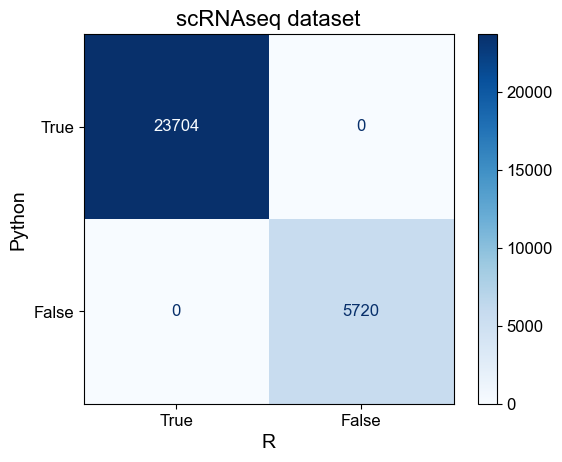

In [342]:
plot_cm(exp, obs, "scRNAseq dataset")

In [ ]:
# formatting data and save as csv

In [147]:
count_df = pd.DataFrame(count_table, index=table.index, columns=table.columns)

In [148]:
meta_data.index = table.index

In [149]:
count_df.to_csv('./dataset/feature_sc.csv')
meta_data.to_csv('./dataset/metadata_sc.csv')

#### Fig2

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import string

In [2]:
plt.rcParams.update({
    'font.size': 14,          # Base text size
    'axes.titlesize': 18,     # Subplot titles
    'axes.labelsize': 16,     # Axis labels (x/y)
    'xtick.labelsize': 14,    # Ticks numbers
    'ytick.labelsize': 14,
    'legend.fontsize': 14,    # Legend text
    'figure.titlesize': 20    # Main figure title (if any)
})

In [ ]:
def plot_cm(ax, matrix, title, subtitle):
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=["True", "False"])
    
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    
    ax.set_xlabel('R')
    ax.set_ylabel('Python')
    ax.set_title(title, pad=25)
    ax.text(0.5, 1.02, subtitle, transform=ax.transAxes, 
        ha='center', va='bottom', fontsize=12, color='gray')
    ax.grid(False)

def plot_grouped_bars(ax, data_a, data_b, title, y_label):
    rects1 =ax.bar(x - width/2, data_a, width, label='R')
    rects2 =ax.bar(x + width/2, data_b, width, label='Python')
    
    ax.bar_label(rects1, padding=3, fmt='%.2f')
    ax.bar_label(rects2, padding=3, fmt='%.2f')


    ax.set_title(title, pad=10)

    ax.set_ylabel(y_label)
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')

    max_val = max(max(data_a), max(data_b))
    ax.set_ylim(0, max_val * 2)
    ax.legend(loc='upper left')

/var/folders/j5/b8wd_rp542sg3k68vnj6cjlw0000gn/T/ipykernel_17173/946275880.py:94: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, max_val * 2)
/var/folders/j5/b8wd_rp542sg3k68vnj6cjlw0000gn/T/ipykernel_17173/946275880.py:94: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, max_val * 2)


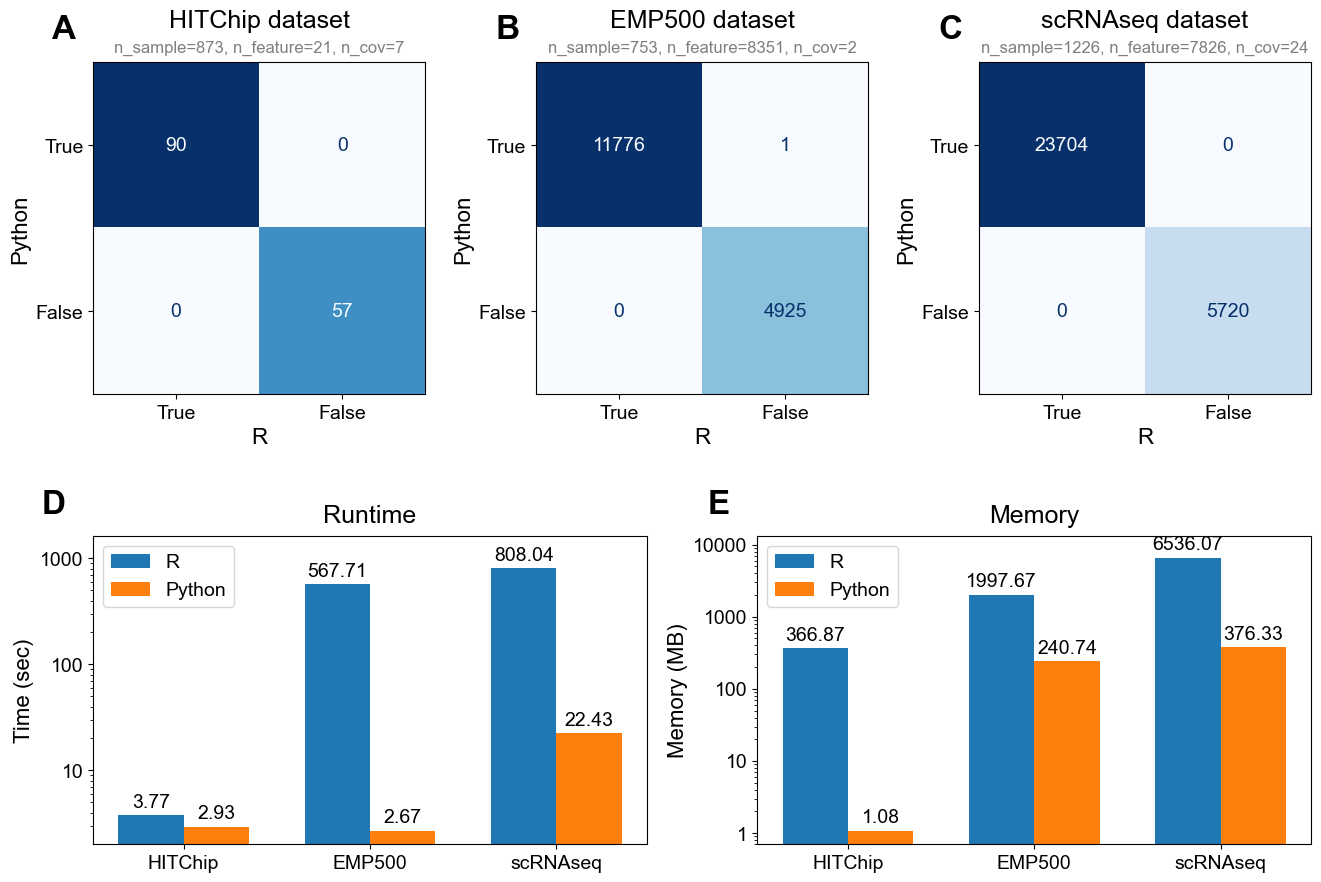

In [106]:
groups = ['HITChip', 'EMP500', 'scRNAseq']
subt = ["n_sample=873, n_feature=21, n_cov=7", 
        "n_sample=753, n_feature=8351, n_cov=2", 
        "n_sample=1226, n_feature=7826, n_cov=24"]
x = np.arange(len(groups))
width = 0.35
s1_dataset_A = [pd.read_csv('benchmark_pseq_r.csv')['Time_Sec'].mean(), 
                pd.read_csv('benchmark_emp_r.csv')['Time_Sec'].mean(),
                pd.read_csv('benchmark_sc_r.csv')['Time_Sec'].mean()]
s1_dataset_B = [pd.read_csv('benchmark_pseq_py.csv')['Time_Sec'].mean(), 
                pd.read_csv('benchmark_emp_py.csv')['Time_Sec'].mean(),
                pd.read_csv('benchmark_sc_py.csv')['Time_Sec'].mean()]

s2_dataset_A = [pd.read_csv('benchmark_pseq_r.csv')['Memory_Used_MB'].mean(), 
                pd.read_csv('benchmark_emp_r.csv')['Memory_Used_MB'].mean(),
                pd.read_csv('benchmark_sc_r.csv')['Memory_Used_MB'].mean()]
s2_dataset_B = [pd.read_csv('benchmark_pseq_py.csv')['Memory_Peak_MB'].mean(), 
                pd.read_csv('benchmark_emp_py.csv')['Memory_Peak_MB'].mean(),
                pd.read_csv('benchmark_sc_py.csv')['Memory_Peak_MB'].mean()]

cm_data = [
    confusion_matrix(exp_pseq.sort_index(axis=1).to_numpy().flatten(), obs_pseq.sort_index(axis=1).to_numpy().flatten().astype(bool)),
    confusion_matrix(exp_emp.sort_index(axis=1).to_numpy().flatten(), obs_emp.sort_index(axis=1).to_numpy().flatten().astype(bool)),
    confusion_matrix(exp.sort_index(axis=1).to_numpy().flatten(), obs.sort_index(axis=1).to_numpy().flatten().astype(bool))
]

fig = plt.figure(figsize=(14, 11)) 

gs = fig.add_gridspec(2, 6, height_ratios=[2, 1], hspace=0, wspace=1) 

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
ax4 = fig.add_subplot(gs[1, 0:3])
ax5 = fig.add_subplot(gs[1, 3:6])

all_axes = [ax1, ax2, ax3, ax4, ax5]

for i, ax in enumerate([ax1, ax2, ax3]):
    plot_cm(ax, cm_data[i], f"{groups[i]} dataset", subt[i])


plot_grouped_bars(ax4, s1_dataset_A, s1_dataset_B, "Runtime", "Time (sec)")
plot_grouped_bars(ax5, s2_dataset_A, s2_dataset_B, "Memory", "Memory (MB)")

# --- Tags ---
tags = string.ascii_uppercase[:5]
for ax, tag in zip(all_axes, tags):
    # Increased fontsize to 24 to keep them dominant
    ax.text(-0.05, 1.05, tag, transform=ax.transAxes, 
            fontsize=24, fontweight='bold', va='bottom', ha='right')

# Adjust margins
plt.subplots_adjust(left=0.08, right=0.95, top=0.92, bottom=0.08)

plt.show()